# Latent-space discovery of metastable dynamical regimes

A metastable region is some neighborhood of an attracting invariant set.

In [1]:
import os
import sys

cur_dir = os.getcwd()
root_dir = os.path.abspath(os.path.join(cur_dir, '..', '..', '..'))
sys.path.append(root_dir)

data_dir = '../../../data/regimes/cavity_fold'

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
from itertools import groupby

import kind
import util_data
import util_nn

### Read windows data

In [2]:
def normalize_standard(timeseries, mean, std):
    return (timeseries - mean) / std

def denormalize_standard(timeseries, mean, std):
    return timeseries * std + mean

class dataset(torch.utils.data.Dataset):
    def __init__(self, back, fore):
        self.back = back
        self.fore = fore

    def __len__(self):
        return len(self.back)

    def __getitem__(self, idx):
        return self.back[idx], self.fore[idx]

# --! read windows data from a file
data_nsample = 72
data = util_data.read_datafile(f'{data_dir}/windows', data_nsample)
print(f'inf > read data shape: {data.shape}')

# --! get normalization constants per channel
std_min = torch.tensor(1e-3, dtype=torch.float32)
data_mean = [d.mean() for d in torch.split(data, 1, dim=-1)]
data_std = [torch.maximum(d.std(), std_min) for d in torch.split(data, 1, dim=-1)]

# --! normalize data
data = torch.cat([
    normalize_standard(
        d, mean, std) for d, mean, std in zip(torch.split(data, 1, dim=-1), data_mean, data_std)], dim=-1)

# --! split windows into lookback and forecast parts
fore_nsample = 24
back_nsample = 2 * fore_nsample
back, fore = torch.split(data, [back_nsample, fore_nsample], dim=-2)

# --! create dataset and dataloader
dataset = dataset(back, fore)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True)

inf > read data shape: torch.Size([15432, 72, 2])


### Instantiate past and future regime encoders

In [3]:
# --! set seed to get reproducible behavior
util_nn.set_seed(2026)

In [4]:
# --! instantiate encoders
window_ndim = data.shape[-1]
latent_ndim = 3
back_enc = kind.regime_encoder(back_nsample, window_ndim, latent_ndim)
fore_enc = kind.regime_encoder(fore_nsample, window_ndim, latent_ndim)

In [5]:
def variance_loss(z):

    std = torch.sqrt(z.var(dim=0) + 1e-4)
    return torch.mean(torch.relu(1.0 - std))

def train_enc(back_enc, fore_enc, dataloader, nepoch=100):
    optimizer = torch.optim.Adam(list(back_enc.parameters()) + list(fore_enc.parameters()), lr=1e-3)

    for epoch in range(nepoch):
        total_loss = 0.0

        for back, fore in dataloader:
            z = back_enc(torch.flatten(back, start_dim=1))
            h = fore_enc(torch.flatten(fore, start_dim=1))
            loss = F.mse_loss(z, h) + 0.01 * variance_loss(z) + 0.01 * variance_loss(h)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        if epoch % 20 == 0:
            print(f"epoch {epoch}, loss: {total_loss / len(dataloader):.6f}")


In [6]:
train_enc(back_enc, fore_enc, dataloader)

epoch 0, loss: 0.012557
epoch 20, loss: 0.000279
epoch 40, loss: 0.000027
epoch 60, loss: 0.000040
epoch 80, loss: 0.000020


In [7]:

# --! once more, prepare lookback and forecast windows
data = util_data.read_datafile(f'{data_dir}/windows', data_nsample)
back, fore = torch.split(data, [back_nsample, fore_nsample], dim=-2)

# --! encode lookback windows
z = back_enc(torch.flatten(back, start_dim=1))
z_np = z.detach().cpu().numpy()


In [8]:
# --! cluster encoded latent space using KMeans --!

ncluster = 3
kmeans = KMeans(n_clusters=ncluster).fit(z_np)


The latent representation is trained using future evolution, causing metastable structures and transition corridors to emerge without labels.

Regime-aware models permit distinct stability assumptions and prediction architectures in different regions of the state space.

Let us formulate the theory as:

Let:
$$z_i = E(w_i)$$
be the learned latent representation with $w_i$ being a lookback window.

Let:
$$\mathcal{N}_1, \dots, \mathcal{N}_m$$
be metastable regions discovered in latent space.

Define
$$\rho(z) = \min_{k \in \text{nominal}} \lVert z, \mathcal{N}_k \rVert.$$

Then
$$\mathcal{N} = \{ \rho < \rho^{\star} \}$$

and
$$\mathcal{E} = \{ \rho \ge \rho^{\star} \}.$$

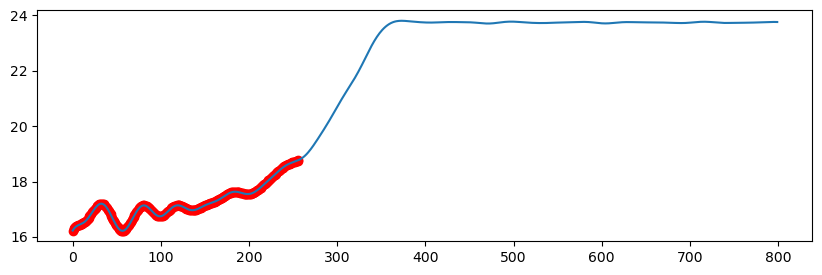

In [9]:
# --! plot discovered clusters ontop of data --!

test_data = data[:800, 48, 0]
test_time = np.arange(len(test_data))
test_kmeans_idx = kmeans.labels_==1
test_kmeans_idx = test_kmeans_idx[:800]

plt.figure(figsize=(10,3))
plt.plot(test_time, test_data)
plt.scatter(test_time[test_kmeans_idx], test_data[test_time[test_kmeans_idx]], color='red')
plt.show()


### Derive cluster interconnections

If a window belongs to cluster $i$, what is the probability that the next window belongs to cluster $j$? Mathematically:

$$P_{i,j} = \Pr \, (c_{t+1} = j \mid c_t = i)$$

In [10]:
prob = np.zeros((ncluster, ncluster))

# --! extract labels for one trajectory to avoid artificial bumps on transitions between trajectories
one_traj_nsample = 1800
labels = kmeans.labels_[:one_traj_nsample]

for i in range(len(labels)-1):
    prob[labels[i], labels[i+1]] += 1

prob /= prob.sum(axis=1, keepdims=True)
print(prob)

# --! compute residence time in each cluster as a list of tuples (cluster index, residence)
residence = [(key, sum(1 for _ in group)) for key, group in groupby(labels)]

# --! sort residence list in descending order, such that
# --! short transition corridors move to the end of this list
sorted_residence = sorted(residence, key=lambda x: x[1])[::-1]
print(sorted_residence)

[[1.         0.         0.        ]
 [0.         0.99610895 0.00389105]
 [0.01265823 0.         0.98734177]]
[(np.int32(0), 1464), (np.int32(1), 257), (np.int32(2), 79)]


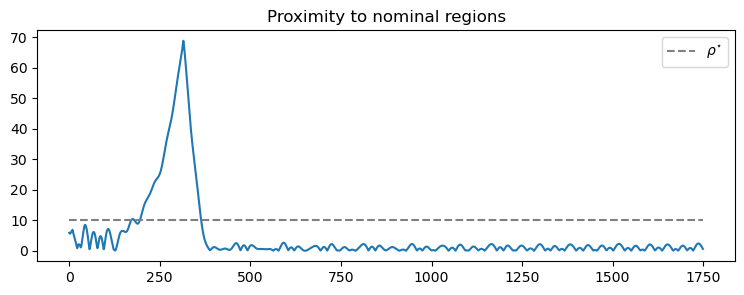

In [11]:
# --! compute proximity to nominal regions --!

centers = kmeans.cluster_centers_
rho = cdist(z_np, centers, metric='euclidean')
rho_nom = np.minimum(rho[:, sorted_residence[0][0]], rho[:, sorted_residence[1][0]])

rho_star = np.percentile(rho_nom, 90)

plt.figure(figsize=(9,3))
plt.title('Proximity to nominal regions')
plt.plot(rho_nom[:1750])
plt.plot([0, 1750], [rho_star, rho_star], color='gray', linestyle='dashed', label=r'$\rho^{\star}$')
plt.legend()
plt.show()

In [12]:
data_idx_nom = rho_nom < rho_star
data_idx_exc = rho_nom >= rho_star
data_nom = data[data_idx_nom]
data_exc = data[data_idx_exc]

print(f'nominal data shape is {data_nom.shape}')
print(f'excursion data shape is {data_exc.shape}')

datasaved = True

if datasaved:
    util_data.write_datafile(f'{data_dir}/nom', data_nom)
    util_data.write_datafile(f'{data_dir}/exc', data_exc)

nominal data shape is torch.Size([13888, 72, 2])
excursion data shape is torch.Size([1544, 72, 2])
